In [1]:
# importing sys
import sys
# This is how you import modules that exist outside of working directory 
# adding mosaique to the system path
sys.path.insert(1, '/home/aasmai/work/QML-QPF/mosaiQue') 
import mosaique as mq
import scipy
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras
import matplotlib.pyplot as plt
# import tensorrt as trt
import tensorflow as tf

2025-11-29 02:15:55.549992: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-29 02:15:55.591026: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2025-11-29 02:15:56.181619: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# --- BLOCK 1: imports ---
import sys
sys.path.insert(1, '/home/aasmai/work/QML-QPF/mosaiQue')

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pennylane as qml
import tensorflow as tf
from tensorflow.keras import models, layers
from keras.callbacks import CSVLogger

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from medmnist import DermaMNIST

# --- BLOCK 2: load dataset (DermaMNIST 64x64) ---
train_data = DermaMNIST(split="train", download=True, size=64)
test_data  = DermaMNIST(split="test",  download=True, size=64)

(tr_images, tr_labels), (te_images, te_labels) = (
    train_data.imgs, train_data.labels
), (
    test_data.imgs, test_data.labels
)

# RGB float [0,1] version
scaled_train_images = tr_images.astype('float32') / 255.0
scaled_test_images  = te_images.astype('float32') / 255.0

print("TRAIN:", tr_images.shape, tr_images.dtype)
print("TEST :", te_images.shape, te_images.dtype)


TRAIN: (7007, 64, 64, 3) uint8
TEST : (2005, 64, 64, 3) uint8


In [3]:
# --- BLOCK 3: CNN builder & trainer ---

def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def run_cnn(X_train, y_train, X_test, y_test, label, out_root):
    """
    X_train/X_test : shape (N,H,W,C)
    label          : 'NO-FILTER', 'A', 'B', 'C'
    out_root       : e.g. 'results_DermaMNIST'
    """
    os.makedirs(out_root, exist_ok=True)
    log_dir  = os.path.join(out_root, "run")
    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, f"{label}.csv")

    csv_logger = CSVLogger(log_file)

    num_classes = int(np.max(y_train)) + 1
    input_shape = X_train.shape[1:]

    model = build_cnn(input_shape, num_classes)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        batch_size=128,
        epochs=5000,           
        verbose=2,
        callbacks=[csv_logger]
    )

    print(f"[{label}] training done. Log → {log_file}")
    return model, history, log_file


In [4]:
# --- BLOCK 4: quantum single-measurement processing for A/B/C ---

def process_qpf_images(
    images_01,     # (N,H,W,3) float in [0,1]
    out_dir,       # output folder
    circuit_type,  # 'A', 'B', or 'C'
    round_decimals=4,
    batch_size=1000
):
    """
    Har pixel ke liye:
      - 3 values (R,G,B) -> qubits 0,1,2 (AngleEmbedding Y)
      - different entanglement / measurement depending on circuit_type
      - expval(Z) ek scalar per pixel
    """
    if images_01.ndim != 4 or images_01.shape[-1] != 3:
        raise ValueError(f"Expected (N,H,W,3), got {images_01.shape}")
    N, H, W, C = images_01.shape
    if images_01.dtype not in (np.float32, np.float64):
        images_01 = images_01.astype(np.float32)

    dev = qml.device("default.qubit.tf", wires=3)

    # ---- define 3 variants ----
    @qml.qnode(dev, interface="tf", diff_method=None)
    @tf.autograph.experimental.do_not_convert
    def circuit_A(x3):
        x3 = x3 * np.pi
        qml.AngleEmbedding(x3, wires=[0, 1, 2], rotation="Y")
        qml.CNOT(wires=[0, 1])   # 0 -> 1
        qml.CNOT(wires=[1, 2])   # 1 -> 2
        return qml.expval(qml.PauliZ(2))  # measure qubit 2

    @qml.qnode(dev, interface="tf", diff_method=None)
    @tf.autograph.experimental.do_not_convert
    def circuit_B(x3):
        x3 = x3 * np.pi
        qml.AngleEmbedding(x3, wires=[0, 1, 2], rotation="Y")
        qml.CNOT(wires=[0, 2])   # 0 -> 2
        qml.CNOT(wires=[1, 2])   # 1 -> 2
        return qml.expval(qml.PauliZ(2))  # measure qubit 2

    @qml.qnode(dev, interface="tf", diff_method=None)
    @tf.autograph.experimental.do_not_convert
    def circuit_C(x3):
        x3 = x3 * np.pi
        qml.AngleEmbedding(x3, wires=[0, 1, 2], rotation="Y")
        qml.CNOT(wires=[1, 0])   # 1 -> 0
        qml.CNOT(wires=[0, 2])   # 0 -> 2
        return qml.expval(qml.PauliZ(2))  # measure qubit 2

    # select which circuit to use
    if circuit_type == "A":
        circ = circuit_A
    elif circuit_type == "B":
        circ = circuit_B
    elif circuit_type == "C":
        circ = circuit_C
    else:
        raise ValueError("circuit_type must be 'A', 'B' or 'C'.")

    @tf.function
    def process_batch(b):  # b: (B,3)
        return tf.vectorized_map(circ, b)

    # ---- unique pixels optimization ----
    flat = images_01.reshape(-1, C)
    rounded = np.round(flat, round_decimals)
    uniq, inv = np.unique(rounded, axis=0, return_inverse=True)

    print(f"[{circuit_type}] unique pixels: {len(uniq)} / {len(flat)}")

    outs = []
    t0 = time.time()
    for i in range(0, len(uniq), batch_size):
        batch = tf.convert_to_tensor(uniq[i:i+batch_size], dtype=tf.float32)
        outs.append(process_batch(batch).numpy())
    uniq_vals = np.concatenate(outs, axis=0).astype(np.float32)

    all_flat = uniq_vals[inv].astype(np.float32)         # (N*H*W,)
    arr = all_flat.reshape(N, H, W)                      # (N,H,W)

    # save CSV
    os.makedirs(out_dir, exist_ok=True)
    csv_path = os.path.join(out_dir, "single_measurement.csv")
    pd.DataFrame({"val_accuracy": all_flat}).to_csv(csv_path, index=False)

    print(f"[{circuit_type}] Saved: {csv_path} rows={all_flat.size} time={time.time()-t0:.2f}s")
    return arr, csv_path


In [5]:
# --- BLOCK 5: loader from CSV to 4D tensor ---

def load_qpf_images(folder, H=64, W=64):
    csv_path = os.path.join(folder, "single_measurement.csv")
    df = pd.read_csv(csv_path)
    vals = df["val_accuracy"].to_numpy(dtype=np.float32)
    pixels_per_img = H * W
    if vals.size % pixels_per_img != 0:
        raise ValueError(f"CSV length {vals.size} not divisible by {pixels_per_img}")
    N = vals.size // pixels_per_img
    arr = vals.reshape(N, H, W)
    arr = arr[..., np.newaxis]  # (N,H,W,1)
    print(f"Loaded QPF images from {csv_path} → {arr.shape}")
    return arr


In [6]:
# --- BLOCK 6: process QPFs & train models ---

results_root = "results_DermaMNIST"   # main root folder

# 1) NO-FILTER baseline
tr_rgb = scaled_train_images  # (7007,64,64,3)
te_rgb = scaled_test_images   # (2005,64,64,3)

print("=== Training NO-FILTER baseline ===")
model_nf, history_nf, log_nf = run_cnn(
    tr_rgb, tr_labels, te_rgb, te_labels,
    label="NO-FILTER",
    out_root=results_root
)

# 2) Circuit A
print("\n=== QPF Circuit A ===")
folder_A_train = os.path.join(results_root, "A_train")
folder_A_test  = os.path.join(results_root, "A_test")
arr_A_train, _ = process_qpf_images(scaled_train_images, folder_A_train, circuit_type="A")
arr_A_test,  _ = process_qpf_images(scaled_test_images,  folder_A_test,  circuit_type="A")

X_A_train = arr_A_train[..., np.newaxis]
X_A_test  = arr_A_test[..., np.newaxis]

model_A, hist_A, log_A = run_cnn(
    X_A_train, tr_labels, X_A_test, te_labels,
    label="A",
    out_root=results_root
)

# 3) Circuit B
print("\n=== QPF Circuit B ===")
folder_B_train = os.path.join(results_root, "B_train")
folder_B_test  = os.path.join(results_root, "B_test")
arr_B_train, _ = process_qpf_images(scaled_train_images, folder_B_train, circuit_type="B")
arr_B_test,  _ = process_qpf_images(scaled_test_images,  folder_B_test,  circuit_type="B")

X_B_train = arr_B_train[..., np.newaxis]
X_B_test  = arr_B_test[..., np.newaxis]

model_B, hist_B, log_B = run_cnn(
    X_B_train, tr_labels, X_B_test, te_labels,
    label="B",
    out_root=results_root
)

# 4) Circuit C
print("\n=== QPF Circuit C ===")
folder_C_train = os.path.join(results_root, "C_train")
folder_C_test  = os.path.join(results_root, "C_test")
arr_C_train, _ = process_qpf_images(scaled_train_images, folder_C_train, circuit_type="C")
arr_C_test,  _ = process_qpf_images(scaled_test_images,  folder_C_test,  circuit_type="C")

X_C_train = arr_C_train[..., np.newaxis]
X_C_test  = arr_C_test[..., np.newaxis]

model_C, hist_C, log_C = run_cnn(
    X_C_train, tr_labels, X_C_test, te_labels,
    label="C",
    out_root=results_root
)


=== Training NO-FILTER baseline ===


2025-11-29 02:15:59.043866: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/5000


55/55 - 2s - 33ms/step - accuracy: 0.6568 - loss: 1.1068 - val_accuracy: 0.6688 - val_loss: 0.9588


Epoch 2/5000


...

Epoch 4999/5000


55/55 - 1s - 19ms/step - accuracy: 0.9986 - loss: 0.0063 - val_accuracy: 0.6893 - val_loss: 19.6346


Epoch 5000/5000


55/55 - 1s - 19ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 0.6808 - val_loss: 19.0525


[C] training done. Log → results_DermaMNIST/run/C.csv


In [7]:
# --- BLOCK 7: evaluation helper ---

def eval_and_report(model, X_test, y_test, tag):
    probs = model.predict(X_test, batch_size=128, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    y_true = y_test.squeeze().astype('int32')

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"\n[{tag}]  Accuracy : {acc:.4f}")
    print(f"[{tag}]  Precision: {prec:.4f}")
    print(f"[{tag}]  Recall   : {rec:.4f}")
    print(f"[{tag}]  F1-score : {f1:.4f}")
    print("\nPer-class report:\n", classification_report(y_true, y_pred, digits=3))

    return acc, prec, rec, f1


# NO-FILTER
acc_nf, prec_nf, rec_nf, f1_nf = eval_and_report(model_nf, te_rgb, te_labels, tag="NO-FILTER")

# A
acc_A, prec_A, rec_A, f1_A = eval_and_report(model_A, X_A_test, te_labels, tag="A")

# B
acc_B, prec_B, rec_B, f1_B = eval_and_report(model_B, X_B_test, te_labels, tag="B")

# C
acc_C, prec_C, rec_C, f1_C = eval_and_report(model_C, X_C_test, te_labels, tag="C")



[NO-FILTER]  Accuracy : 0.7302
[NO-FILTER]  Precision: 0.6988
[NO-FILTER]  Recall   : 0.7302
[NO-FILTER]  F1-score : 0.6991

Per-class report:
               precision    recall  f1-score   support

           0      0.449     0.333     0.383        66
           1      0.391     0.417     0.404       103
           2      0.470     0.250     0.326       220
           3      0.750     0.130     0.222        23
           4      0.538     0.287     0.374       223
           5      0.794     0.940     0.861      1341
           6      0.889     0.552     0.681        29

    accuracy                          0.730      2005
   macro avg      0.612     0.416     0.464      2005
weighted avg      0.699     0.730     0.699      2005


[A]  Accuracy : 0.6963
[A]  Precision: 0.6440
[A]  Recall   : 0.6963
[A]  F1-score : 0.6471

Per-class report:
               precision    recall  f1-score   support

           0      0.409     0.136     0.205        66
           1      0.396     0.184   


[B]  Accuracy : 0.6893
[B]  Precision: 0.6248
[B]  Recall   : 0.6893
[B]  F1-score : 0.6323

Per-class report:
               precision    recall  f1-score   support

           0      0.800     0.121     0.211        66
           1      0.438     0.136     0.207       103
           2      0.376     0.227     0.283       220
           3      0.000     0.000     0.000        23
           4      0.339     0.188     0.242       223
           5      0.743     0.946     0.832      1341
           6      0.000     0.000     0.000        29

    accuracy                          0.689      2005
   macro avg      0.385     0.231     0.254      2005
weighted avg      0.625     0.689     0.632      2005


[C]  Accuracy : 0.6808
[C]  Precision: 0.6223
[C]  Recall   : 0.6808
[C]  F1-score : 0.6307

Per-class report:
               precision    recall  f1-score   support

           0      0.571     0.121     0.200        66
           1      0.444     0.155     0.230       103
           2  

/home/aasmai/miniconda3/envs/qml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aasmai/miniconda3/envs/qml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aasmai/miniconda3/envs/qml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

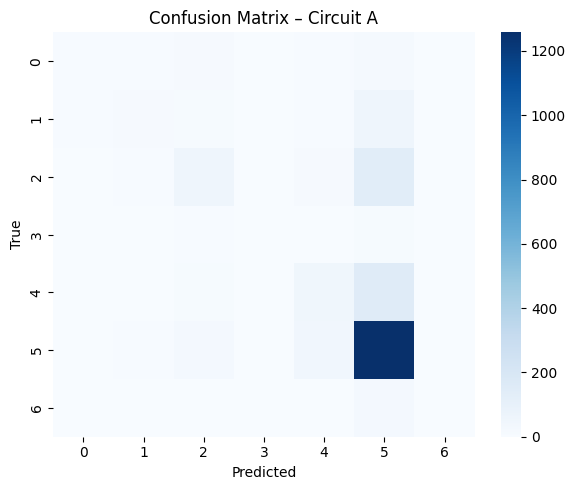

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

probs = model_A.predict(X_A_test, batch_size=128, verbose=0)
y_pred = np.argmax(probs, axis=1)
y_true = te_labels.squeeze().astype('int32')

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title('Confusion Matrix – Circuit A')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.show()


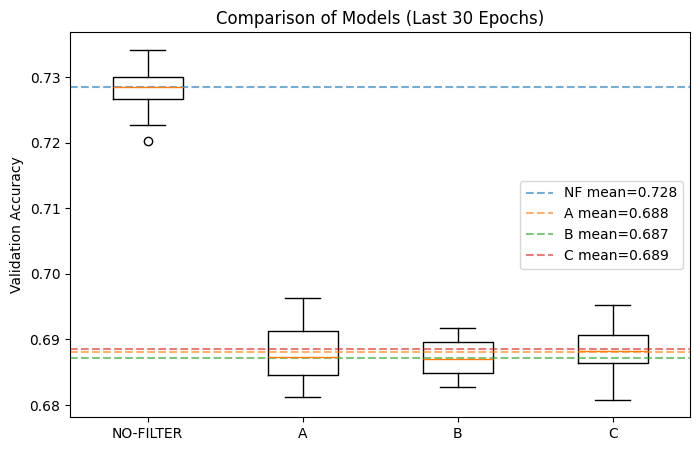

In [9]:
# --- BLOCK 8: boxplot comparison of val_accuracy (last 30 epochs) ---

def last30_val_acc(log_csv):
    df = pd.read_csv(log_csv)
    return df['val_accuracy'].tail(30).astype(float).tolist()

vals_nf = last30_val_acc(log_nf)
vals_A  = last30_val_acc(log_A)
vals_B  = last30_val_acc(log_B)
vals_C  = last30_val_acc(log_C)

plt.figure(figsize=(8,5))
plt.boxplot(
    [vals_nf, vals_A, vals_B, vals_C],
    labels=['NO-FILTER', 'A', 'B', 'C']
)
plt.ylabel('Validation Accuracy')
plt.title('Comparison of Models (Last 30 Epochs)')

# horizontal mean lines
means = [np.mean(vals_nf), np.mean(vals_A), np.mean(vals_B), np.mean(vals_C)]
colors = ['C0', 'C1', 'C2', 'C3']
for i, m in enumerate(means):
    plt.axhline(m, color=colors[i], linestyle='--', alpha=0.6,
                label=f'{["NF","A","B","C"][i]} mean={m:.3f}')

plt.legend()
plt.show()
